In [1]:
import os

# Change this to your actual dataset path
DATASET_PATH = "C:\\Users\\bhand\\Downloads\\Bharatanatyam-Mudra-Dataset-master"  # or full path like "C:/Users/YourName/Downloads/mudras"

# Check it's working
classes = sorted(os.listdir(DATASET_PATH))
print(f"Total classes found: {len(classes)}")
print(f"Classes: {classes}")

Total classes found: 50
Classes: ['Alapadmam(1)', 'Anjali(1)', 'Aralam(1)', 'Ardhachandran(1)', 'Ardhapathaka(1)', 'Berunda(1)', 'Bramaram(1)', 'Chakra(1)', 'Chandrakala(1)', 'Chaturam(1)', 'Garuda(1)', 'Hamsapaksha(1)', 'Hamsasyam(1)', 'Kangulam(1)', 'Kapith(1)', 'Kapotham(1)', 'Karkatta(1)', 'Kartariswastika(1)', 'Katakamukha_1', 'Katakamukha_2', 'Katakamukha_3', 'Katakavardhana(1)', 'Katrimukha(1)', 'Khatva(1)', 'Kilaka(1)', 'Kurma(1)', 'Matsya(1)', 'Mayura(1)', 'Mrigasirsha(1)', 'Mukulam(1)', 'Mushti(1)', 'Nagabandha(1)', 'Padmakosha(1)', 'Pasha(1)', 'Pathaka(1)', 'Pushpaputa(1)', 'Sakata(1)', 'Samputa(1)', 'Sarpasirsha(1)', 'Shanka(1)', 'Shivalinga(1)', 'Shukatundam(1)', 'Sikharam(1)', 'Simhamukham(1)', 'Suchi(1)', 'Swastikam(1)', 'Tamarachudam(1)', 'Tripathaka(1)', 'Trishulam(1)', 'Varaha(1)']


In [4]:
import pandas as pd

class_counts = {}
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        class_counts[cls] = count

df = pd.DataFrame(list(class_counts.items()), columns=['Mudra', 'Count'])
df = df.sort_values('Count', ascending=False)

print(f"Total images: {df['Count'].sum()}")
print(f"Min images in a class: {df['Count'].min()} ({df.iloc[-1]['Mudra']})")
print(f"Max images in a class: {df['Count'].max()} ({df.iloc[0]['Mudra']})")
print(df)

Total images: 28431
Min images in a class: 455 (Bramaram(1))
Max images in a class: 769 (Katakavardhana(1))
                 Mudra  Count
21   Katakavardhana(1)    769
45        Swastikam(1)    745
39           Shanka(1)    724
35       Pushpaputa(1)    723
17  Kartariswastika(1)    681
40       Shivalinga(1)    681
15         Kapotham(1)    669
26           Matsya(1)    663
37          Samputa(1)    648
10           Garuda(1)    633
2            Aralam(1)    615
36           Sakata(1)    614
7            Chakra(1)    610
25            Kurma(1)    602
1            Anjali(1)    593
31       Nagabandha(1)    577
4      Ardhapathaka(1)    577
5           Berunda(1)    573
29          Mukulam(1)    571
11      Hamsapaksha(1)    569
34          Pathaka(1)    568
12        Hamsasyam(1)    565
22       Katrimukha(1)    564
38      Sarpasirsha(1)    563
48        Trishulam(1)    560
28      Mrigasirsha(1)    559
41      Shukatundam(1)    559
46     Tamarachudam(1)    559
14           Kapith(1)

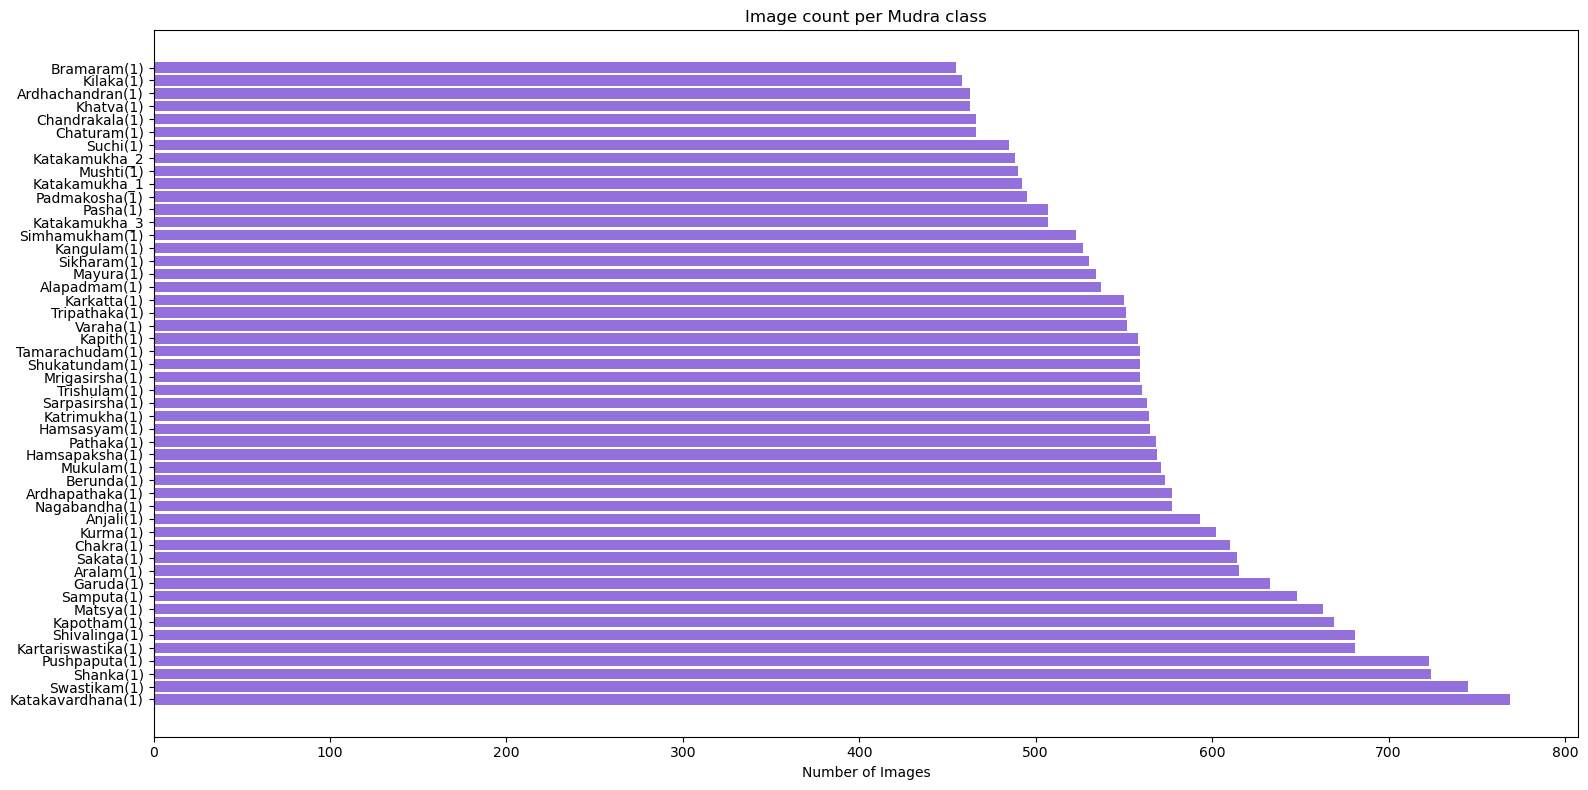

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 8))
plt.barh(df['Mudra'], df['Count'], color='mediumpurple')
plt.xlabel('Number of Images')
plt.title('Image count per Mudra class')
plt.tight_layout()
plt.show()

In [7]:
for item in sorted(os.listdir(DATASET_PATH)):
    full_path = os.path.join(DATASET_PATH, item)
    if os.path.isdir(full_path):
        img_count = len([f for f in os.listdir(full_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"{item:30s} → {img_count} images")
    else:
        print(f"{item:30s} → FILE (not a folder)")

Alapadmam(1)                   → 537 images
Anjali(1)                      → 593 images
Aralam(1)                      → 615 images
Ardhachandran(1)               → 463 images
Ardhapathaka(1)                → 577 images
Berunda(1)                     → 573 images
Bramaram(1)                    → 455 images
Chakra(1)                      → 610 images
Chandrakala(1)                 → 466 images
Chaturam(1)                    → 466 images
Garuda(1)                      → 633 images
Hamsapaksha(1)                 → 569 images
Hamsasyam(1)                   → 565 images
Kangulam(1)                    → 527 images
Kapith(1)                      → 558 images
Kapotham(1)                    → 669 images
Karkatta(1)                    → 550 images
Kartariswastika(1)             → 681 images
Katakamukha_1                  → 492 images
Katakamukha_2                  → 488 images
Katakamukha_3                  → 507 images
Katakavardhana(1)              → 769 images
Katrimukha(1)                  →

Total classes: 50


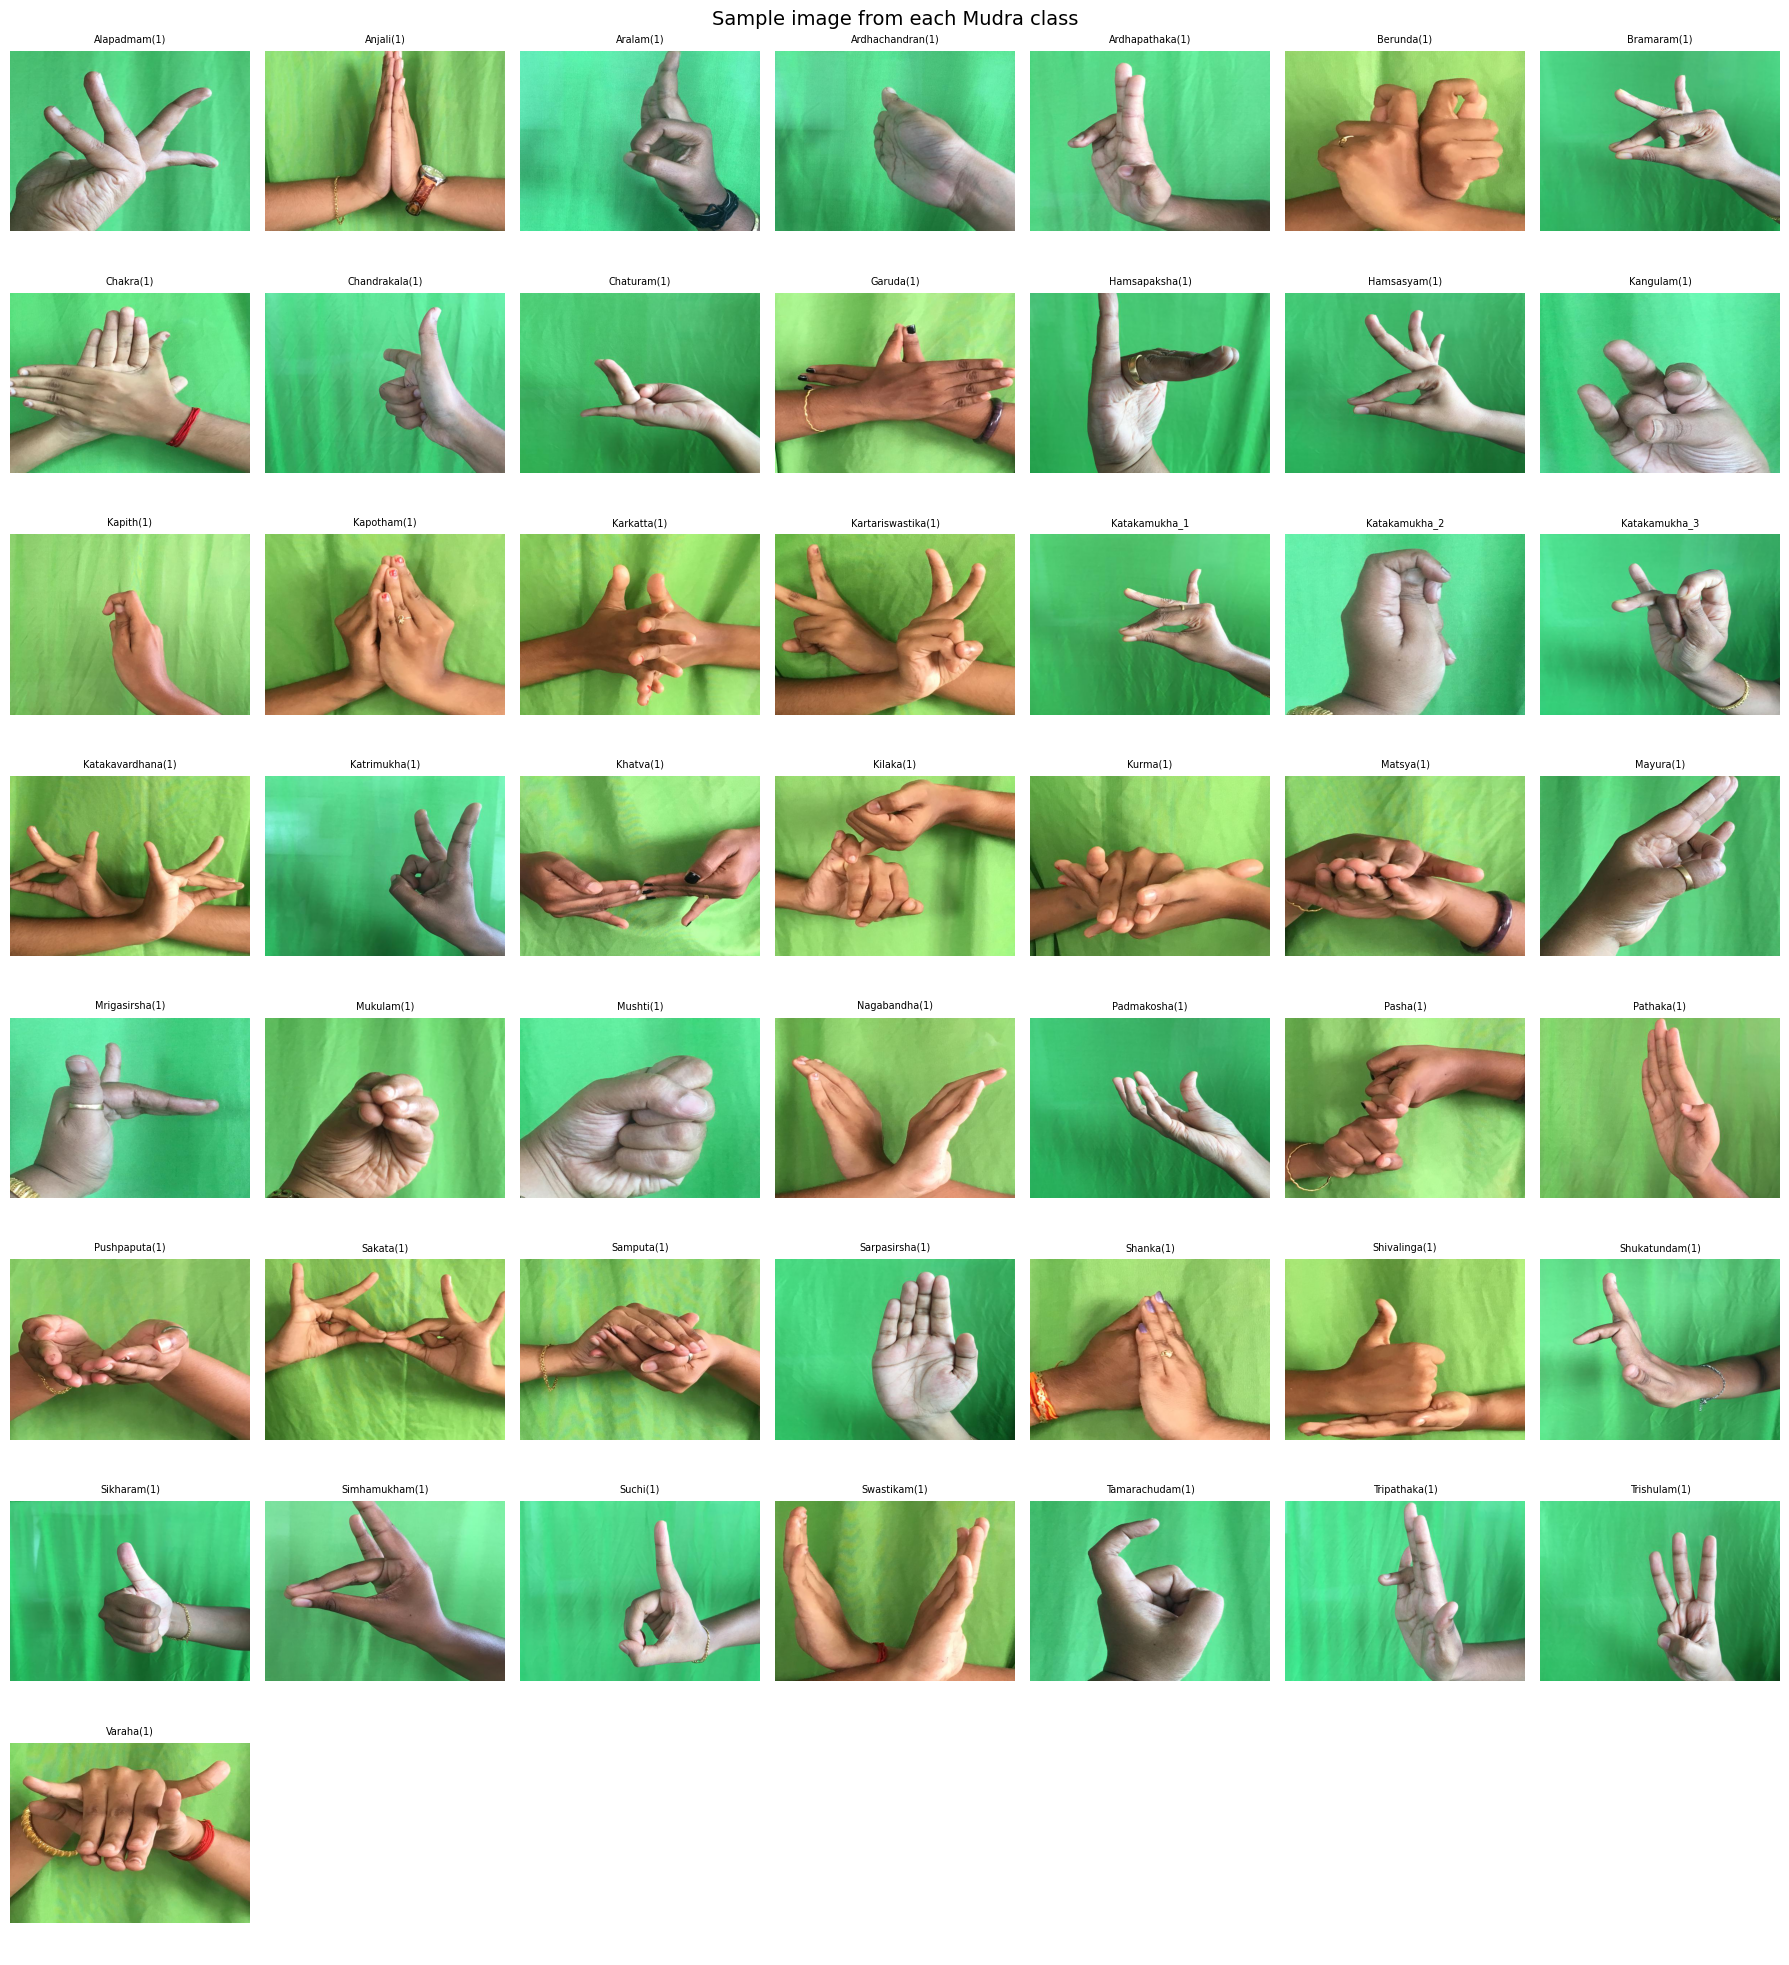

In [8]:
from PIL import Image
import random
import math

valid_classes = sorted([
    cls for cls in os.listdir(DATASET_PATH) 
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])

print(f"Total classes: {len(valid_classes)}")

cols = 7
rows = math.ceil(len(valid_classes) / cols)  # = 8 rows for 50 classes

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 2.5))
axes = axes.flatten()

for i, cls in enumerate(valid_classes):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(images) == 0:
        continue
    sample = random.choice(images)
    img = Image.open(os.path.join(cls_path, sample))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=7)
    axes[i].axis('off')

for j in range(len(valid_classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample image from each Mudra class', fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
widths, heights = [], []

for cls in valid_classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img_file in images[:20]:
        img = Image.open(os.path.join(cls_path, img_file))
        w, h = img.size
        widths.append(w)
        heights.append(h)

print(f"Width  — min: {min(widths)}, max: {max(widths)}, avg: {int(sum(widths)/len(widths))}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, avg: {int(sum(heights)/len(heights))}")

Width  — min: 666, max: 666, avg: 666
Height — min: 500, max: 500, avg: 500


In [14]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import mediapipe as mp

# New API for mediapipe 0.10.30+
BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print(f"✅ MediaPipe {mp.__version__} loaded!")

✅ MediaPipe 0.10.32 loaded!


In [17]:
import urllib.request

model_path = "hand_landmarker.task"

if not os.path.exists(model_path):
    print("Downloading hand landmarker model...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
    urllib.request.urlretrieve(url, model_path)
    print("✅ Model downloaded!")
else:
    print("✅ Model already exists!")

✅ Model already exists!


✅ Hands detected: 1


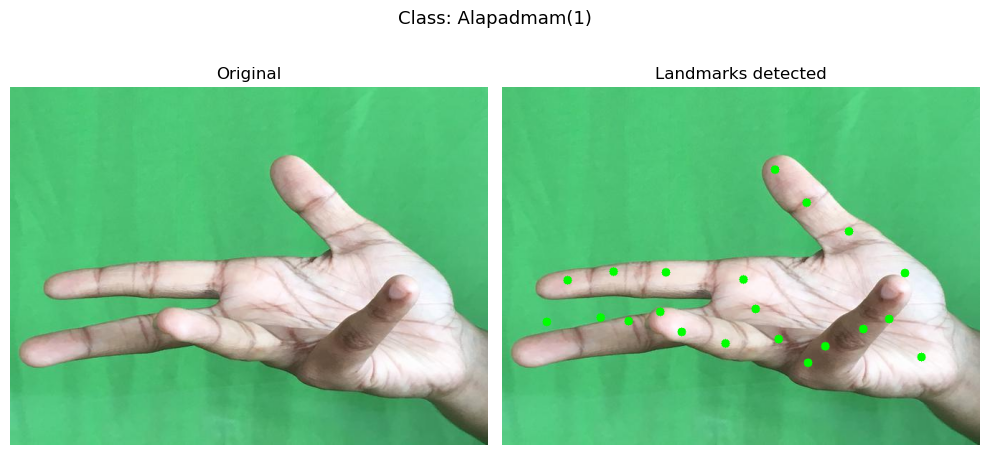

In [18]:
# Setup landmarker
options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.3
)

# Pick sample image
sample_class = valid_classes[0]
sample_folder = os.path.join(DATASET_PATH, sample_class)
sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

# Read and process
img = cv2.imread(sample_image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)

with HandLandmarker.create_from_options(options) as landmarker:
    results = landmarker.detect(mp_image)

# Draw landmarks manually (no connection lines, just points)
img_display = img_rgb.copy()
if results.hand_landmarks:
    print(f"✅ Hands detected: {len(results.hand_landmarks)}")
    for hand in results.hand_landmarks:
        h, w, _ = img_rgb.shape
        for lm in hand:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(img_display, (cx, cy), 6, (0, 255, 0), -1)
else:
    print("❌ No hands detected")

# Show
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_display)
plt.title("Landmarks detected")
plt.axis('off')

plt.suptitle(f"Class: {sample_class}", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
from tqdm import tqdm

IMAGE_SIZE = (224, 224)

X_images = []
X_landmarks = []
y_labels = []
failed = []

options = HandLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
    running_mode=VisionRunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.3
)

with HandLandmarker.create_from_options(options) as landmarker:
    for cls in tqdm(valid_classes, desc="Processing classes"):
        cls_path = os.path.join(DATASET_PATH, cls)
        images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        for img_file in images:
            img_path = os.path.join(cls_path, img_file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, IMAGE_SIZE)
            
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            results = landmarker.detect(mp_image)
            
            if results.hand_landmarks:
                lm_array = []
                for hand in results.hand_landmarks:
                    for lm in hand:
                        lm_array.extend([lm.x, lm.y, lm.z])
                
                # Pad to fixed size (2 hands × 21 points × 3 = 126)
                lm_array = lm_array[:126]
                lm_array += [0.0] * (126 - len(lm_array))
                
                X_images.append(img_resized)
                X_landmarks.append(lm_array)
                y_labels.append(cls)
            else:
                failed.append(img_path)

print(f"\n✅ Processed: {len(X_images)} images")
print(f"❌ No hand detected: {len(failed)} images")
print(f"Detection rate: {len(X_images)/(len(X_images)+len(failed))*100:.1f}%")

Processing classes: 100%|██████████████████████████████████████████████████████████████| 50/50 [13:10<00:00, 15.81s/it]


✅ Processed: 23808 images
❌ No hand detected: 3878 images
Detection rate: 86.0%


In [20]:
import numpy as np

X_images = np.array(X_images, dtype='uint8')
X_landmarks = np.array(X_landmarks, dtype='float32')
y_labels = np.array(y_labels)

print(f"X_images shape: {X_images.shape}")
print(f"X_landmarks shape: {X_landmarks.shape}")
print(f"y_labels shape: {y_labels.shape}")
print(f"Unique classes: {len(np.unique(y_labels))}")

# Save to disk
np.save('X_images.npy', X_images)
np.save('X_landmarks.npy', X_landmarks)
np.save('y_labels.npy', y_labels)

print("\n✅ Saved successfully!")

X_images shape: (23808, 224, 224, 3)
X_landmarks shape: (23808, 126)
y_labels shape: (23808,)
Unique classes: 49

✅ Saved successfully!


In [21]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Encode string labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
y_categorical = to_categorical(y_encoded)

print(f"Classes: {list(le.classes_)}")
print(f"y_encoded shape: {y_encoded.shape}")
print(f"y_categorical shape: {y_categorical.shape}")
print(f"Number of classes: {len(le.classes_)}")

# Save label encoder
import pickle
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("✅ Label encoder saved!")

Classes: [np.str_('Alapadmam(1)'), np.str_('Anjali(1)'), np.str_('Aralam(1)'), np.str_('Ardhachandran(1)'), np.str_('Ardhapathaka(1)'), np.str_('Berunda(1)'), np.str_('Bramaram(1)'), np.str_('Chakra(1)'), np.str_('Chandrakala(1)'), np.str_('Chaturam(1)'), np.str_('Garuda(1)'), np.str_('Hamsapaksha(1)'), np.str_('Hamsasyam(1)'), np.str_('Kangulam(1)'), np.str_('Kapith(1)'), np.str_('Kapotham(1)'), np.str_('Karkatta(1)'), np.str_('Kartariswastika(1)'), np.str_('Katakamukha_1'), np.str_('Katakamukha_2'), np.str_('Katakamukha_3'), np.str_('Katakavardhana(1)'), np.str_('Katrimukha(1)'), np.str_('Khatva(1)'), np.str_('Kilaka(1)'), np.str_('Kurma(1)'), np.str_('Matsya(1)'), np.str_('Mayura(1)'), np.str_('Mrigasirsha(1)'), np.str_('Mukulam(1)'), np.str_('Mushti(1)'), np.str_('Nagabandha(1)'), np.str_('Padmakosha(1)'), np.str_('Pasha(1)'), np.str_('Pathaka(1)'), np.str_('Pushpaputa(1)'), np.str_('Sakata(1)'), np.str_('Samputa(1)'), np.str_('Sarpasirsha(1)'), np.str_('Shanka(1)'), np.str_('Shiva

In [23]:
from sklearn.model_selection import train_test_split
import numpy as np

# Work with indices only — no memory issues
indices = np.arange(len(X_images))

# Split indices
idx_temp, idx_test = train_test_split(
    indices, test_size=0.15, random_state=42, stratify=y_encoded
)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=0.176, random_state=42, stratify=y_encoded[idx_temp]
)

print(f"Train set:      {len(idx_train)} images")
print(f"Validation set: {len(idx_val)} images")
print(f"Test set:       {len(idx_test)} images")
print(f"Total:          {len(idx_train)+len(idx_val)+len(idx_test)} images")

# Save indices
np.save('idx_train.npy', idx_train)
np.save('idx_val.npy', idx_val)
np.save('idx_test.npy', idx_test)
print("✅ Indices saved!")

Train set:      16674 images
Validation set: 3562 images
Test set:       3572 images
Total:          23808 images
✅ Indices saved!


In [28]:
import tensorflow as tf
import numpy as np

BATCH_SIZE = 32
NUM_CLASSES = len(le.classes_)

X_images_mmap = np.load('X_images.npy', mmap_mode='r')
X_landmarks_mmap = np.load('X_landmarks.npy', mmap_mode='r')

def batch_generator(indices, shuffle=False):
    while True:  # ← keeps generating indefinitely
        if shuffle:
            indices = np.random.permutation(indices)
        
        for start in range(0, len(indices), BATCH_SIZE):
            batch_idx = indices[start:start + BATCH_SIZE]
            imgs = X_images_mmap[batch_idx].astype('float32') / 255.0
            lms  = X_landmarks_mmap[batch_idx].astype('float32')
            lbls = to_categorical(y_encoded[batch_idx], NUM_CLASSES)
            yield {"image_input": imgs, "landmark_input": lms}, lbls

def make_dataset(indices, shuffle=False):
    ds = tf.data.Dataset.from_generator(
        lambda: batch_generator(indices, shuffle),
        output_signature=(
            {
                "image_input":    tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
                "landmark_input": tf.TensorSpec(shape=(None, 126),         dtype=tf.float32)
            },
            tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
        )
    ).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(idx_train, shuffle=True)
val_ds   = make_dataset(idx_val)
test_ds  = make_dataset(idx_test)

print("✅ Datasets ready!")

✅ Datasets ready!


In [29]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, concatenate, BatchNormalization
from tensorflow.keras.optimizers import Adam

IMG_SHAPE = (224, 224, 3)

# Image branch
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False

img_input = Input(shape=IMG_SHAPE, name='image_input')
x = base_model(img_input, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Landmark branch
lm_input = Input(shape=(126,), name='landmark_input')
lm = Dense(128, activation='relu')(lm_input)
lm = BatchNormalization()(lm)
lm = Dropout(0.3)(lm)
lm = Dense(64, activation='relu')(lm)

# Combine
combined = concatenate([x, lm])
combined = Dense(256, activation='relu')(combined)
combined = Dropout(0.4)(combined)
output = Dense(NUM_CLASSES, activation='softmax')(combined)

model = Model(inputs=[img_input, lm_input], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"✅ Model built! Total classes: {NUM_CLASSES}")
model.summary()


✅ Model built! Total classes: 49


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ landmark_input (InputLayer)   │ (None, 126)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)        │       2,257,984 │ image_input[0][0]          │
│ (Functional)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 128)               │          16,256 │ landmark_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling2d_1    │ (None, 1280)              │               0 │ mobilenetv2_1.00_224[0][0] │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 128)               │             512 │ dense_4[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 1280)              │           5,120 │ global_average_pooling2d_… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 128)               │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 1280)              │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 64)                │           8,256 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 1344)              │               0 │ dropout_3[0][0],           │
│                               │                           │                 │ dense_5[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 256)               │         344,320 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_5 (Dropout)           │ (None, 256)               │               0 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 49)                │          12,593 │ dropout_5[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,645,041 (10.09 MB)

 Trainable params: 384,241 (1.47 MB)

 Non-trainable params: 2,260,800 (8.62 MB)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

steps_per_epoch = len(idx_train) // BATCH_SIZE
validation_steps = len(idx_val) // BATCH_SIZE

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('mudranet_best_v2.h5', save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)

print("✅ Training complete!")

Epoch 1/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.7472 - loss: 0.8684
Epoch 1: val_loss improved from None to 0.13597, saving model to mudranet_best_v2.h5



Epoch 1: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 328s 630ms/step - accuracy: 0.8197 - loss: 0.5957 - val_accuracy: 0.9609 - val_loss: 0.1360 - learning_rate: 0.0010
Epoch 2/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9078 - loss: 0.2836
Epoch 2: val_loss improved from 0.13597 to 0.07405, saving model to mudranet_best_v2.h5



Epoch 2: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 1572s 3s/step - accuracy: 0.9196 - loss: 0.2496 - val_accuracy: 0.9783 - val_loss: 0.0740 - learning_rate: 0.0010
Epoch 3/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9410 - loss: 0.1756
Epoch 3: val_loss improved from 0.07405 to 0.06710, saving model to mudranet_best_v2.h5



Epoch 3: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 1343s 3s/step - accuracy: 0.9453 - loss: 0.1660 - val_accuracy: 0.9828 - val_loss: 0.0671 - learning_rate: 0.0010
Epoch 4/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9587 - loss: 0.1311
Epoch 4: val_loss improved from 0.06710 to 0.05774, saving model to mudranet_best_v2.h5



Epoch 4: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.9581 - loss: 0.1282 - val_accuracy: 0.9828 - val_loss: 0.0577 - learning_rate: 0.0010
Epoch 5/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 0.9482 - loss: 0.1534
Epoch 5: val_loss improved from 0.05774 to 0.05736, saving model to mudranet_best_v2.h5


...


Epoch 7: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 305s 586ms/step - accuracy: 0.9651 - loss: 0.1116 - val_accuracy: 0.9890 - val_loss: 0.0487 - learning_rate: 0.0010
Epoch 8/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9658 - loss: 0.1066
Epoch 8: val_loss did not improve from 0.04866
521/521 ━━━━━━━━━━━━━━━━━━━━ 304s 584ms/step - accuracy: 0.9664 - loss: 0.1037 - val_accuracy: 0.9870 - val_loss: 0.0527 - learning_rate: 0.0010
Epoch 9/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.9725 - loss: 0.0850
Epoch 9: val_loss improved from 0.04866 to 0.04590, saving model to mudranet_best_v2.h5



Epoch 9: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 308s 591ms/step - accuracy: 0.9723 - loss: 0.0887 - val_accuracy: 0.9893 - val_loss: 0.0459 - learning_rate: 0.0010
Epoch 10/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.9702 - loss: 0.1024
Epoch 10: val_loss did not improve from 0.04590
521/521 ━━━━━━━━━━━━━━━━━━━━ 300s 576ms/step - accuracy: 0.9689 - loss: 0.1031 - val_accuracy: 0.9868 - val_loss: 0.0560 - learning_rate: 0.0010
Epoch 11/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.9626 - loss: 0.1192
Epoch 11: val_loss did not improve from 0.04590
521/521 ━━━━━━━━━━━━━━━━━━━━ 328s 630ms/step - accuracy: 0.9662 - loss: 0.1066 - val_accuracy: 0.9907 - val_loss: 0.0462 - learning_rate: 0.0010
Epoch 12/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9754 - loss: 0.0828
Epoch 12: val_loss did not improve from 0.04590

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
521/521 ━━━━━━━━━━━━━


Epoch 13: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step - accuracy: 0.9779 - loss: 0.0656 - val_accuracy: 0.9927 - val_loss: 0.0382 - learning_rate: 5.0000e-04
Epoch 14/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9841 - loss: 0.0520
Epoch 14: val_loss did not improve from 0.03819
521/521 ━━━━━━━━━━━━━━━━━━━━ 683s 1s/step - accuracy: 0.9840 - loss: 0.0494 - val_accuracy: 0.9918 - val_loss: 0.0399 - learning_rate: 5.0000e-04
Epoch 15/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9813 - loss: 0.0609
Epoch 15: val_loss improved from 0.03819 to 0.03365, saving model to mudranet_best_v2.h5



Epoch 15: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 359s 690ms/step - accuracy: 0.9833 - loss: 0.0522 - val_accuracy: 0.9938 - val_loss: 0.0337 - learning_rate: 5.0000e-04
Epoch 16/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9849 - loss: 0.0422
Epoch 16: val_loss did not improve from 0.03365
521/521 ━━━━━━━━━━━━━━━━━━━━ 356s 684ms/step - accuracy: 0.9864 - loss: 0.0410 - val_accuracy: 0.9918 - val_loss: 0.0402 - learning_rate: 5.0000e-04
Epoch 17/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9849 - loss: 0.0482
Epoch 17: val_loss improved from 0.03365 to 0.03240, saving model to mudranet_best_v2.h5



Epoch 17: finished saving model to mudranet_best_v2.h5
521/521 ━━━━━━━━━━━━━━━━━━━━ 364s 700ms/step - accuracy: 0.9858 - loss: 0.0447 - val_accuracy: 0.9927 - val_loss: 0.0324 - learning_rate: 5.0000e-04
Epoch 18/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9848 - loss: 0.0451
Epoch 18: val_loss did not improve from 0.03240
521/521 ━━━━━━━━━━━━━━━━━━━━ 358s 688ms/step - accuracy: 0.9860 - loss: 0.0432 - val_accuracy: 0.9921 - val_loss: 0.0371 - learning_rate: 5.0000e-04
Epoch 19/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9851 - loss: 0.0393
Epoch 19: val_loss did not improve from 0.03240
521/521 ━━━━━━━━━━━━━━━━━━━━ 305s 585ms/step - accuracy: 0.9870 - loss: 0.0375 - val_accuracy: 0.9916 - val_loss: 0.0366 - learning_rate: 5.0000e-04
Epoch 20/20
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9876 - loss: 0.0379
Epoch 20: val_loss did not improve from 0.03240

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
521/521 

In [32]:
# Evaluate on test set
test_steps = len(idx_test) // BATCH_SIZE
results = model.evaluate(test_ds, steps=test_steps)
print(f"\n🎯 Test Accuracy: {results[1]*100:.2f}%")
print(f"📉 Test Loss:     {results[0]:.4f}")

111/111 ━━━━━━━━━━━━━━━━━━━━ 58s 520ms/step - accuracy: 0.9938 - loss: 0.0399

🎯 Test Accuracy: 99.38%
📉 Test Loss:     0.0399


                    precision    recall  f1-score   support

      Alapadmam(1)       1.00      1.00      1.00        55
         Anjali(1)       0.99      1.00      0.99        89
         Aralam(1)       0.95      1.00      0.98        83
  Ardhachandran(1)       1.00      1.00      1.00        68
   Ardhapathaka(1)       1.00      0.97      0.98        62
        Berunda(1)       1.00      1.00      1.00        83
       Bramaram(1)       0.97      1.00      0.98        60
         Chakra(1)       1.00      1.00      1.00        90
    Chandrakala(1)       0.98      1.00      0.99        64
       Chaturam(1)       1.00      1.00      1.00        63
         Garuda(1)       1.00      1.00      1.00        95
    Hamsapaksha(1)       0.97      0.97      0.97        35
      Hamsasyam(1)       1.00      0.97      0.98        66
       Kangulam(1)       1.00      0.96      0.98        50
         Kapith(1)       0.99      0.99      0.99        74
       Kapotham(1)       1.00      1.00

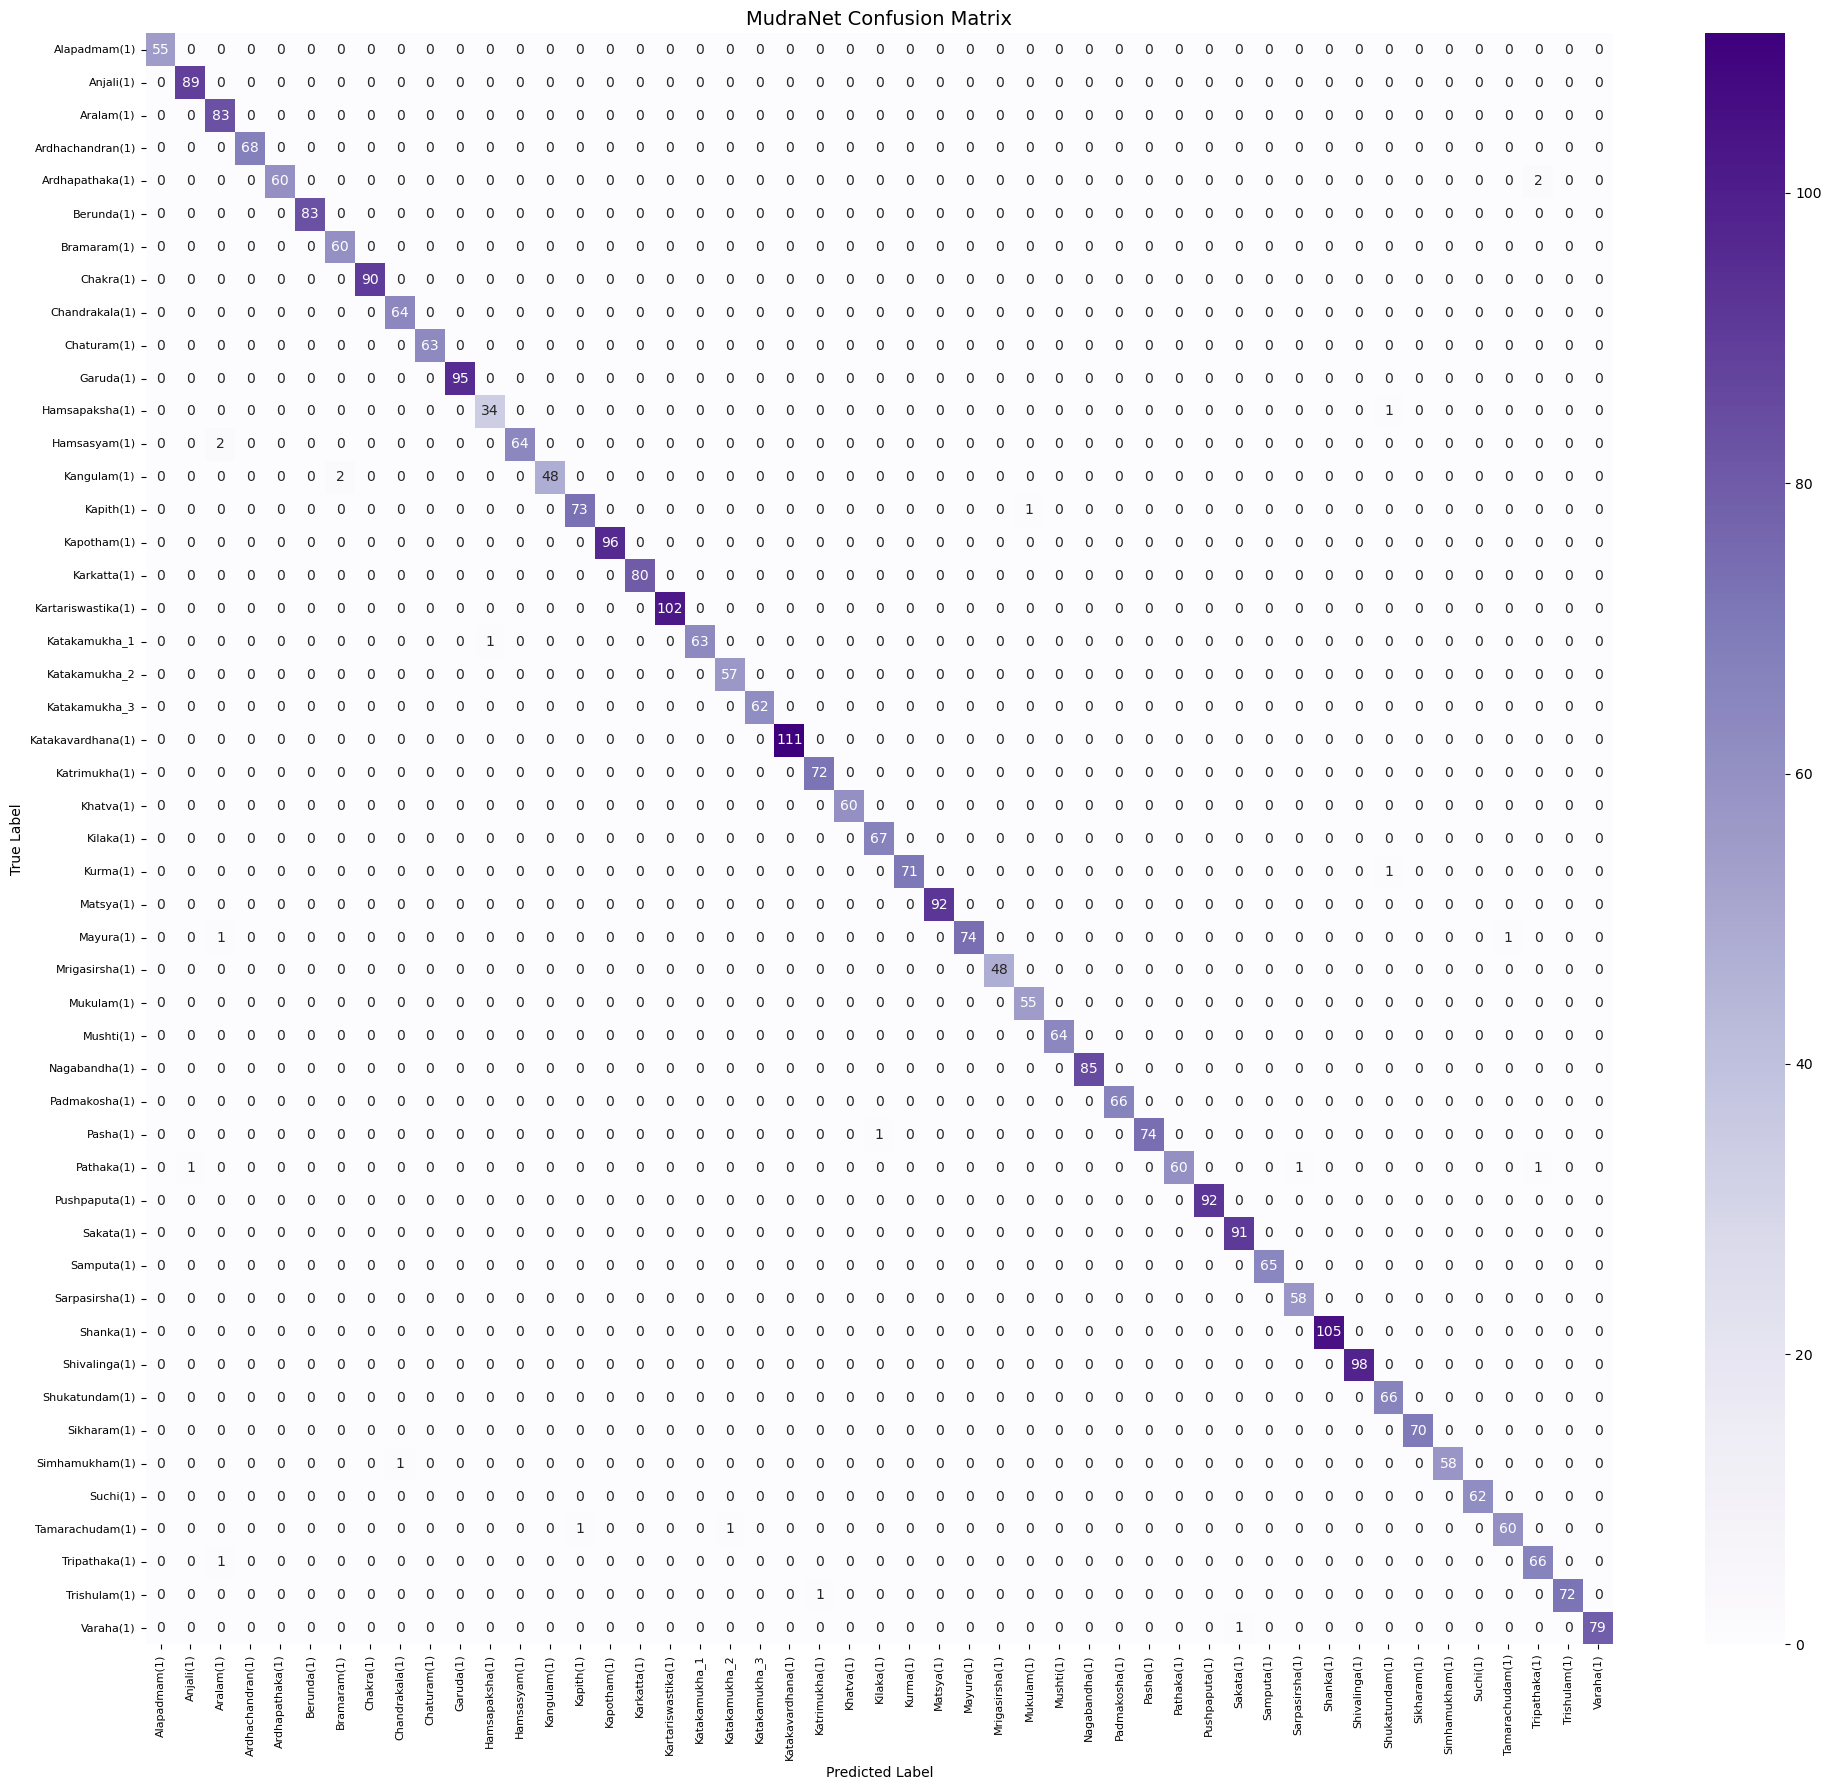

✅ Confusion matrix saved!


In [38]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred, y_true = [], []

for (inputs, lbls) in test_ds.take(test_steps):
    preds = model.predict(inputs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(lbls.numpy(), axis=1))

y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Classification report
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('MudraNet Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

In [41]:
# Save in modern keras format (no more HDF5 warning)
model.save('mudranet_final.keras')
print("✅ Model saved as mudranet_final.keras")

# Also save class names for the app
import json
class_names = list(le.classes_)
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)
print(f"✅ Saved {len(class_names)} class names")

✅ Model saved as mudranet_final.keras
✅ Saved 49 class names


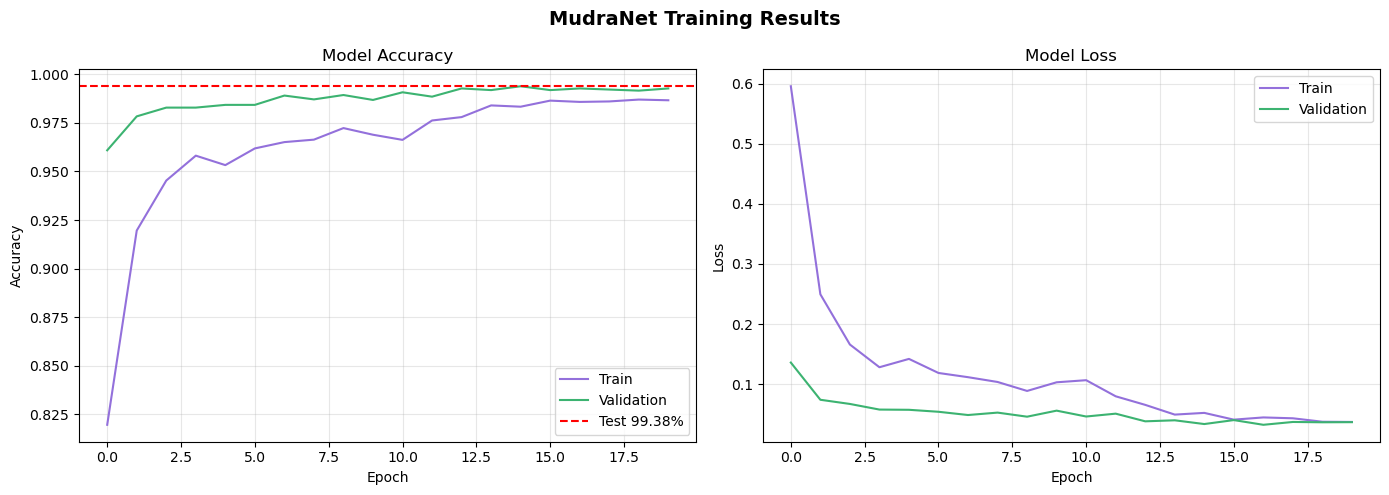

✅ Plot saved as training_history.png


In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', color='mediumpurple')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='mediumseagreen')
axes[0].axhline(y=0.9938, color='red', linestyle='--', label='Test 99.38%')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', color='mediumpurple')
axes[1].plot(history.history['val_loss'], label='Validation', color='mediumseagreen')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MudraNet Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("✅ Plot saved as training_history.png")

In [4]:
app_code = '''import streamlit as st
import numpy as np
import cv2
import json
import mediapipe as mp
from tensorflow.keras.models import load_model

@st.cache_resource
def load_assets():
    model = load_model("mudranet_final.keras")
    with open("class_names.json") as f:
        class_names = json.load(f)
    return model, class_names

model, class_names = load_assets()

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

@st.cache_resource
def load_landmarker():
    options = HandLandmarkerOptions(
        base_options=BaseOptions(model_asset_path="hand_landmarker.task"),
        running_mode=VisionRunningMode.IMAGE,
        num_hands=2,
        min_hand_detection_confidence=0.3
    )
    return HandLandmarker.create_from_options(options)

landmarker = load_landmarker()

mudra_meanings = {
    "Pathaka(1)": "Flag - used to depict sky, forest, or waving",
    "Tripathaka(1)": "Three part flag - used for crown or tree",
    "Ardhapathaka(1)": "Half flag - used for knife or tower",
    "Mayura(1)": "Peacock - used to depict a peacock or stroking hair",
    "Anjali(1)": "Salutation - used for greeting or prayer",
    "Katakamukha_1": "Opening in a link - used for holding a garland",
    "Katakamukha_2": "Katakamukha variant 2 - used for picking flowers",
    "Katakamukha_3": "Katakamukha variant 3 - used for delicate gestures",
    "Alapadmam(1)": "Full blown lotus - used for beauty or moon",
    "Mushti(1)": "Fist - used for holding or strength",
    "Sikharam(1)": "Spire - used for bow or pillar",
    "Kapith(1)": "Wood apple - used for goddess Lakshmi",
    "Suchi(1)": "Needle - used for pointing or the world",
    "Chandrakala(1)": "Moon digit - used for moon or forehead mark",
    "Padmakosha(1)": "Lotus bud - used for fruits or a ball",
    "Sarpasirsha(1)": "Snake head - used for elephant or snake",
    "Mrigasirsha(1)": "Deer head - used for deer or woman face",
    "Simhamukham(1)": "Lion face - used for lion or valour",
    "Kangulam(1)": "Used for fruits or hanging objects",
    "Mukulam(1)": "Bud - used for eating or lotus bud",
    "Aralam(1)": "Curved - used for wind god or drinking nectar",
    "Shukatundam(1)": "Parrot beak - used for parrot or arrow",
    "Bramaram(1)": "Bee - used for bee or fighting",
    "Hamsasyam(1)": "Swan face - used for painting or fine work",
    "Hamsapaksham(1)": "Swan wing - used for swan or moonlight",
    "Tamarachudam(1)": "Cock - used for cock or peacock feather",
    "Trishulam(1)": "Trident - used for Lord Shiva trident",
    "Katrimukha(1)": "Scissors face - used for opposition or separation",
    "Ardhachandran(1)": "Half moon - used for moon or blessing",
    "Chaturam(1)": "Clever - used for gold or clever person",
    "Swastikam(1)": "Auspicious symbol - used for sacred occasions",
    "Kapotham(1)": "Dove - used for respectful salutation",
    "Karkatta(1)": "Crab - used for crab or interlocking fingers",
    "Pushpaputa(1)": "Handful of flowers - used for offering flowers",
    "Shivalinga(1)": "Symbol of Lord Shiva",
    "Katakavardhana(1)": "Used for coronation ceremonies",
    "Kartariswastika(1)": "Scissors crossed - used for opposition",
    "Sakata(1)": "Carriage - used for demon or carriage",
    "Shanka(1)": "Conch shell - used for conch or pure being",
    "Chakra(1)": "Wheel - used for wheel or discus",
    "Samputa(1)": "Covered box - used for box or secret",
    "Pasha(1)": "Noose - used for bond or rope",
    "Kilaka(1)": "Bond - used for friendship or bonding",
    "Matsya(1)": "Fish - used to depict a fish",
    "Kurma(1)": "Tortoise - used to depict a tortoise",
    "Varaha(1)": "Boar - used for boar avatar of Vishnu",
    "Garuda(1)": "Eagle - used for Garuda or bird",
    "Nagabandha(1)": "Snake bond - used for intertwined snakes",
    "Khatva(1)": "Cot - used for cot or bedstead",
    "Berunda(1)": "Two headed bird - used for power",
}

def extract_landmarks(img_rgb):
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    results = landmarker.detect(mp_image)
    if results.hand_landmarks:
        lm_array = []
        for hand in results.hand_landmarks:
            for lm in hand:
                lm_array.extend([lm.x, lm.y, lm.z])
        lm_array = lm_array[:126]
        lm_array += [0.0] * (126 - len(lm_array))
        return np.array(lm_array, dtype="float32"), results
    return None, results

def draw_landmarks(img_rgb, results):
    img_display = img_rgb.copy()
    if results.hand_landmarks:
        h, w, _ = img_rgb.shape
        for hand in results.hand_landmarks:
            points = [(int(lm.x * w), int(lm.y * h)) for lm in hand]
            for pt in points:
                cv2.circle(img_display, pt, 6, (0, 255, 0), -1)
    return img_display

def predict(img_rgb):
    img_resized = cv2.resize(img_rgb, (224, 224)).astype("float32") / 255.0
    lm_array, results = extract_landmarks(img_rgb)
    if lm_array is not None:
        img_input = np.expand_dims(img_resized, axis=0)
        lm_input = np.expand_dims(lm_array, axis=0)
        preds = model.predict({"image_input": img_input, "landmark_input": lm_input}, verbose=0)
        top3_idx = np.argsort(preds[0])[::-1][:3]
        return preds[0], top3_idx, results
    return None, None, results

st.set_page_config(page_title="MudraNet", page_icon="🤚", layout="wide")
st.title("🤚 MudraNet: Bharatiya Natya Mudra Identifier")
st.markdown("Identify Bharatanatyam hand gestures using your laptop camera or by uploading an image.")

mode = st.radio("Choose input mode", ["📷 Live Camera", "🖼️ Upload Image"], horizontal=True)

if mode == "📷 Live Camera":
    st.info("Tick the checkbox to start camera. Your hand gesture will be predicted in real time.")
    run = st.checkbox("▶️ Start Camera")
    FRAME_WINDOW = st.empty()
    result_placeholder = st.empty()

    if run:
        cap = cv2.VideoCapture(0)
        if not cap.isOpened():
            st.error("Cannot access camera. Make sure no other app is using it.")
        else:
            while run:
                ret, frame = cap.read()
                if not ret:
                    st.error("Failed to read from camera.")
                    break
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                preds, top3_idx, results = predict(frame_rgb)
                frame_lm = draw_landmarks(frame_rgb, results)
                FRAME_WINDOW.image(frame_lm, channels="RGB", use_container_width=True)
                if preds is not None:
                    predicted_class = class_names[top3_idx[0]]
                    confidence = preds[top3_idx[0]] * 100
                    meaning = mudra_meanings.get(predicted_class, "Meaning not available")
                    result_placeholder.success(f"**{predicted_class}** — {confidence:.1f}% confidence\\n\\n📖 {meaning}")
                else:
                    result_placeholder.warning("No hand detected — show your hand clearly to the camera")
            cap.release()

else:
    uploaded_file = st.file_uploader("Upload hand gesture image", type=["jpg", "jpeg", "png"])
    if uploaded_file:
        file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
        img_bgr = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        preds, top3_idx, results = predict(img_rgb)
        img_lm = draw_landmarks(img_rgb, results)
        col1, col2, col3 = st.columns(3)
        with col1:
            st.subheader("Original")
            st.image(img_rgb, use_container_width=True)
        with col2:
            st.subheader("Landmarks")
            st.image(img_lm, use_container_width=True)
        with col3:
            st.subheader("Prediction")
            if preds is not None:
                predicted_class = class_names[top3_idx[0]]
                confidence = preds[top3_idx[0]] * 100
                meaning = mudra_meanings.get(predicted_class, "Meaning not available")
                st.success(f"**{predicted_class}**")
                st.metric("Confidence", f"{confidence:.1f}%")
                st.info(f"📖 {meaning}")
                st.subheader("Top 3 Predictions")
                for idx in top3_idx:
                    name = class_names[idx]
                    prob = preds[idx] * 100
                    st.progress(int(prob), text=f"{name}: {prob:.1f}%")
            else:
                st.error("No hand detected. Try a clearer image.")
'''
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!


In [5]:
import subprocess
subprocess.Popen(['streamlit', 'run', 'app.py'])
print("✅ Streamlit launching...")
print("Open your browser and go to: http://localhost:8501")

✅ Streamlit launching...
Open your browser and go to: http://localhost:8501
